In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("Social_Network_Ads.csv")
df.head()

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


In [3]:
df.Purchased.value_counts()

Purchased
0    257
1    143
Name: count, dtype: int64

In [4]:
df.dtypes

User ID             int64
Gender             object
Age                 int64
EstimatedSalary     int64
Purchased           int64
dtype: object

count    400.000000
mean      37.655000
std       10.482877
min       18.000000
25%       29.750000
50%       37.000000
75%       46.000000
max       60.000000
Name: Age, dtype: float64


<Axes: ylabel='Age'>

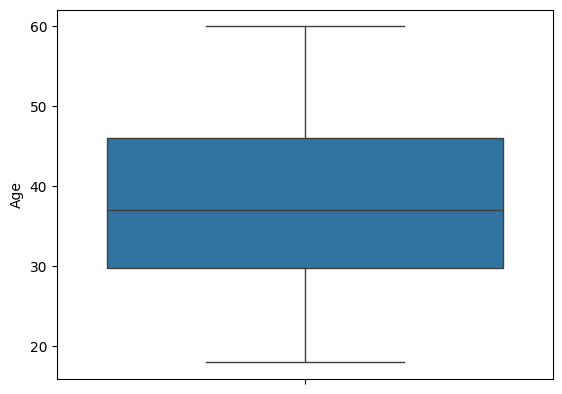

In [5]:
print(df["Age"].describe()) #Give statiscal data about Age like mean ,mode,median etc
sns.boxplot(data=df["Age"])#to anaylze and visulaize the dataset ,detect outliers etc

Convert Categorical to Numeric = Label Encoding

In [ ]:
df.loc[df["Gender"] == "Male", "Gender"] = 0
df.loc[df["Gender"] == "Female", "Gender"] = 1

Age range → 18 to 60
Salary range → 15000 to 150000 
salary values are larger we so model will give more imp to salary 
sacling will make the both features between 0 and 1
And will Improve the Performnce.

In [8]:
def min_max_normalize(feature): #function for future use
    df[feature] = (df[feature] - df[feature].min()) / (df[feature].max() - df[feature].min()) #mn-max formula

min_max_normalize("EstimatedSalary")
min_max_normalize("Age")

X → Independent variables (Gender, Age, Salary)
y → Target variable (Purchased)

In [9]:
X = np.asarray(df.drop(["Purchased"], axis=1)) # 1 means column 0 means row
y = np.asarray(df["Purchased"])

Training Data (70%)
Testing Data (30%)
if not tested or train data it will give Accuracy high 

In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)

Apply Logistic Regression

In [13]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X_train, y_train)

LogisticRegression()

In [15]:
y_pred = model.predict(X_test) # using testing data it will Predict

Accuracy

In [16]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

Confusion Matrix

In [18]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
cm

array([[75,  4],
       [10, 31]])

Here Confusion matrix is giving
TN=75    FP=4
FN=10    TP=31

In [19]:
tp = ((y_pred == 1) & (y_test == 1)).sum() # will give true positive
tn = ((y_pred == 0) & (y_test == 0)).sum()  #True Negative
fp = ((y_pred == 1) & (y_test == 0)).sum()   #False Positive predicted 1 but actual; is 0
fn = ((y_pred == 0) & (y_test == 1)).sum()    #False Negative

In [20]:
recall = tp/(tp + fn)
accuracy = (tp + tn)/(tp + fp + tn + fn)
precision = tp / (tp + fp)
error = 1 - accuracy
f1 = (2 * recall * precision)/(recall + precision)


In [21]:
print("Recall: ", recall)
print("Precision: ", precision)
print("Accuracy: ", accuracy)
print("F1 Score: ", f1)

Recall:  0.7560975609756098
Precision:  0.8857142857142857
Accuracy:  0.8833333333333333
F1 Score:  0.8157894736842105


In [22]:
import matplotlib.pyplot as plt

# Filter only purchased = 1
purchased_data = df[df['Purchased'] == 1]

# Count male and female
gender_count = purchased_data['Gender'].value_counts()

print(gender_count)

Gender
1    77
0    66
Name: count, dtype: int64
